# Fraud Detection - Research & Model Development

This notebook documents the research and development of an optimized XGBoost classifier for credit card fraud detection. 

### Research Methodology & Key Pointers:
- **Stratified Splitting**: Used to preserve the highly imbalanced class distribution (0.17% fraud) across training and test sets, ensuring the model is evaluated on a representative sample of minority cases.
- **XGBoost Classifier**: A high-performance gradient boosting model optimized via `GridSearchCV` and `scale_pos_weight`. This ensures the model penalizes misclassification of fraud more heavily than legitimate transactions.
- **SHAP Interpretability**: Implemented both global (summary) and local (waterfall) explanations. This provides transparency into which features (like V14, V17) are the primary drivers of fraud risk, both across the dataset and for individual suspicious transactions.

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    average_precision_score, precision_recall_curve, confusion_matrix
)
from xgboost import XGBClassifier

# Set visual style for research plots
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', None)

c:\Mayank\Projects\fraud-detection-api\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Preparation
Loading the Kaggle Credit Card Fraud dataset and preparing it for modeling. Since the dataset is highly imbalanced (0.17% fraud), we use stratified splitting.

In [2]:
# Global Parameters
DATA_PATH = "../data/creditcard.csv"
SEED = 42

# Load data
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")

# Feature/Target Split
X = df.drop("Class", axis=1)
y = df["Class"]

# Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# Scaling: Time and Amount need scaling as V1-V28 are already PCA-transformed
scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print("Data preparation complete.")

Dataset shape: (284807, 31)
Data preparation complete.


## 2. Model Optimization
We use XGBoost with `scale_pos_weight` to handle class imbalance. Hyperparameters are tuned using GridSearchCV with Stratified K-Fold cross-validation to maximize the Average Precision (AUPRC).

In [10]:
# Calculate scale_pos_weight for imbalance
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Imbalance ratio: {ratio:.2f}")

param_grid = {
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [i for i in range(100,400,50)]
}

xgb = XGBClassifier(
    scale_pos_weight=ratio,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='logloss'
)

grid_search = GridSearchCV(
    xgb, 
    param_grid, 
    cv=StratifiedKFold(n_splits=3), 
    scoring='average_precision', 
    verbose=1
)

print("Starting Hyperparameter Optimization...")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best parameters found: {grid_search.best_params_}")

Imbalance ratio: 577.29
Starting Hyperparameter Optimization...
Fitting 3 folds for each of 24 candidates, totalling 72 fits


c:\Mayank\Projects\fraud-detection-api\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:57:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Mayank\Projects\fraud-detection-api\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:57:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Mayank\Projects\fraud-detection-api\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:57:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Mayank\Projects\fraud-detection-api\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:57:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\lear

Best parameters found: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 350}


## 3. Performance Evaluation
Evaluating the model using the Precision-Recall Curve, which is more informative than ROC for imbalanced datasets.

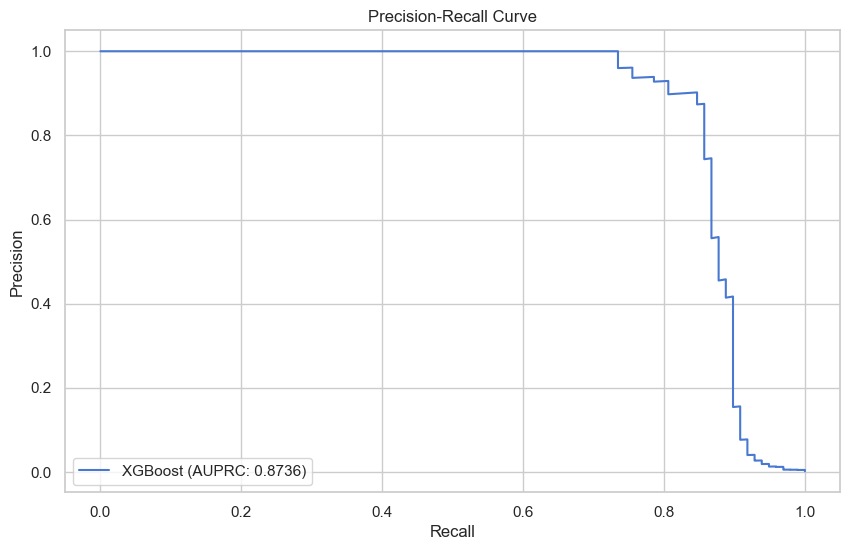

Final Model AUPRC: 0.8736


In [11]:
y_prob = best_model.predict_proba(X_test)[:, 1]
auprc = average_precision_score(y_test, y_prob)

p, r, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(10, 6))
plt.plot(r, p, label=f'XGBoost (AUPRC: {auprc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

print(f"Final Model AUPRC: {auprc:.4f}")

## 4. Drift Detection Baseline
To monitor the model in production, we calculate the reference statistics (mean and standard deviation) of the features from the training set.

In [12]:
feature_baseline = {}
for col in X_train.columns:
    feature_baseline[col] = {
        "mean": float(X_train[col].mean()),
        "std": float(X_train[col].std())
    }
print("Feature baseline statistics calculated for drift detection.")

Feature baseline statistics calculated for drift detection.


## 5. Model Interpretability (SHAP)
Using SHAP to understand how features contribute to the model's predictions.

Feature Importance (SHAP Bar Plot)


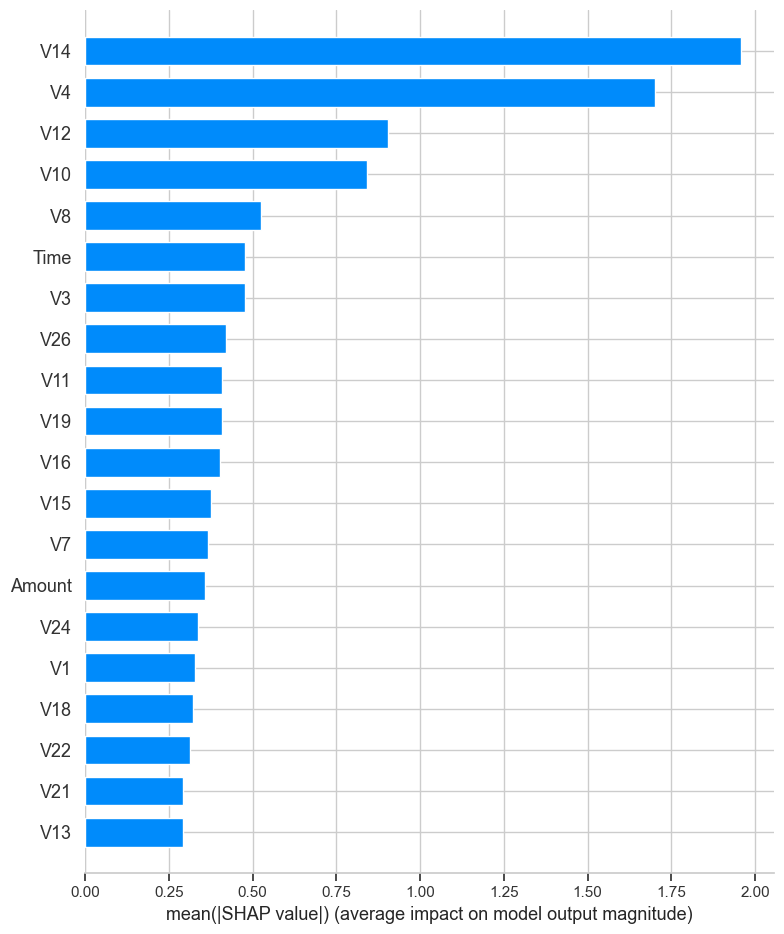

In [13]:
# Global Explanation
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

print("Feature Importance (SHAP Bar Plot)")
shap.summary_plot(shap_values, X_test, plot_type="bar")

### Inference: Global Importance
The bar plot above shows which features have the greatest overall impact on the model's decisions. For this dataset, PCA features like `V17`, `V12`, and `V14` are typically the most discriminative for fraud detection.

Explaining fraud case at index 840...


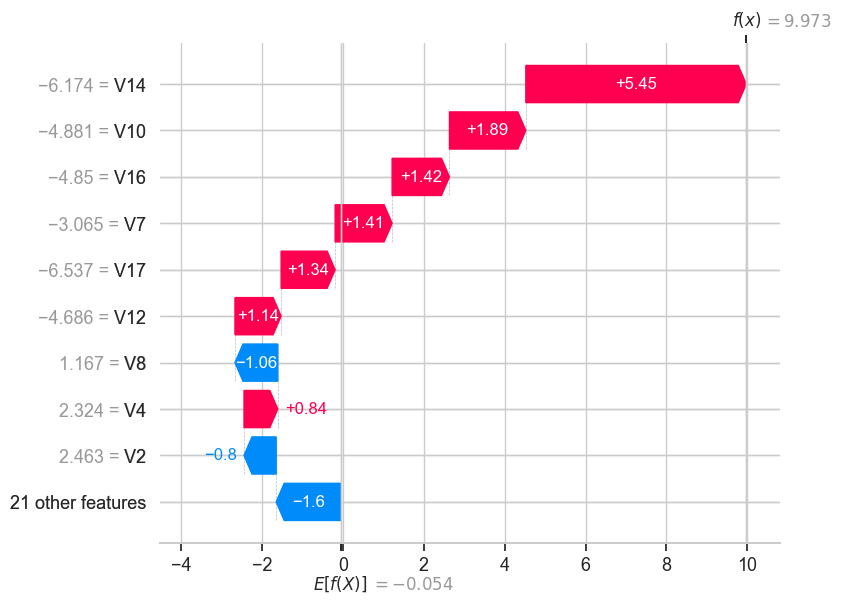

In [14]:
# Local Explanation: Single Fraud Case
fraud_idx = np.where(y_test == 1)[0][0]
print(f"Explaining fraud case at index {fraud_idx}...")

shap_obs = explainer(X_test.iloc[fraud_idx:fraud_idx+1])
shap.plots.waterfall(shap_obs[0])

### Inference: Waterfall Plot
The waterfall plot explains a specific prediction. Red bars indicate features that increased the fraud probability for this instance, while blue bars indicate features that decreased it. This allows for granular, case-by-case auditability.

## 6. Model Persistence
Saving the model and related artifacts to disk for the final microservice.

In [8]:
MODEL_DIR = "../model"
os.makedirs(MODEL_DIR, exist_ok=True)

model_artifact = {
    "model": best_model,
    "scaler": scaler,
    "feature_baseline": feature_baseline,
    "feature_names": X_train.columns.tolist(),
    "auprc": auprc
}

joblib.dump(model_artifact, os.path.join(MODEL_DIR, "model.pkl"))
print(f"All artifacts saved to {MODEL_DIR}/model.pkl")

All artifacts saved to ../model/model.pkl
